## Проверка при помощи python библиотеки 

In [19]:
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

# Матрица расстояний
distance_matrix = [
    [99999, 4, 5, 7, 5],
    [8, 99999, 5, 6, 6],
    [3, 5, 99999, 9, 6],
    [3, 5, 6, 99999, 2],
    [6, 2, 3, 8, 99999],
]


# Создание диспетчера данных
def create_data_model():
    data = {}
    data["distance_matrix"] = distance_matrix
    data["num_vehicles"] = 1
    data["depot"] = 0
    return data

# Решение задачи коммивояжёра
def solve_tsp():
    data = create_data_model()
    manager = pywrapcp.RoutingIndexManager(len(data["distance_matrix"]), data["num_vehicles"], data["depot"])
    routing = pywrapcp.RoutingModel(manager)

    # Функция стоимости (расстояния)
    transit_callback_index = routing.RegisterTransitCallback(lambda from_index, to_index:
        data["distance_matrix"][manager.IndexToNode(from_index)][manager.IndexToNode(to_index)])

    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Используем стратегию полного перебора (AUTOMATIC, включает Branch & Bound)
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.AUTOMATIC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.seconds = 30
    # Решение
    solution = routing.SolveWithParameters(search_parameters)

    # Вывод маршрута
    if solution:
        route = []
        index = routing.Start(0)
        while not routing.IsEnd(index):
            route.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))
        route.append(manager.IndexToNode(index))
        return route
    else:
        return None

# Запуск решения
optimal_route = solve_tsp()
if optimal_route:
    city_labels = ["A", "B", "C", "D", "E"]
    route_names = [city_labels[i] for i in optimal_route]
    print("Оптимальный маршрут:", " → ".join(route_names))
else:
    print("Решение не найдено.")

Оптимальный маршрут: A → B → D → E → C → A


## Метаэвристический алгоритм
Попробуем решить задачу коммивояжера с помощью генетического алгоритма.

In [7]:
import random
import numpy as np

# Матрица расстояний
distance_matrix = [
    [float('inf'), 4, 5, 7, 5],
    [8, float('inf'), 5, 6, 6],
    [3, 5, float('inf'), 9, 6],
    [3, 5, 6, float('inf'), 2],
    [6, 2, 3, 8, float('inf')],
]

# Заменяем inf на максимальное расстояние
max_value = 99999
for i in range(len(distance_matrix)):
    distance_matrix[i][i] = max_value

# Генерация начальной популяции
def generate_population(size, n):
    population = []
    for _ in range(size):
        individual = list(range(n))
        random.shuffle(individual)
        population.append(individual)
    return population

# Вычисление стоимости маршрута
def calculate_cost(route):
    cost = 0
    for i in range(len(route) - 1):
        cost += distance_matrix[route[i]][route[i + 1]]
    cost += distance_matrix[route[-1]][route[0]]  # Возврат в начальную точку
    return cost

# Селекция (выбор лучших родителей)
def selection(population, costs, num_parents):
    selected_parents = np.argsort(costs)[:num_parents]
    return [population[i] for i in selected_parents]

# Операция скрещивания (смешивание двух родителей)
def crossover(parent1, parent2):
    start, end = sorted(random.sample(range(len(parent1)), 2))
    child = [-1] * len(parent1)
    child[start:end+1] = parent1[start:end+1]
    
    current_index = 0
    for gene in parent2:
        if gene not in child:
            while child[current_index] != -1:
                current_index += 1
            child[current_index] = gene
    return child

# Операция мутации (случайная перестановка двух элементов)
def mutate(child):
    if random.random() < 0.2:  # 20% вероятность мутации
        i, j = random.sample(range(len(child)), 2)
        child[i], child[j] = child[j], child[i]
    return child

# Основная функция генетического алгоритма
def genetic_algorithm(population_size, generations, n_cities):
    population = generate_population(population_size, n_cities)
    
    for generation in range(generations):
        # Оценка стоимости каждого маршрута
        costs = [calculate_cost(individual) for individual in population]
        
        # Печать текущего лучшего решения
        best_cost = min(costs)
        best_route = population[costs.index(best_cost)]
        # print(f"Generation {generation}: Best Cost = {best_cost}, Route = {best_route}")
        
        # Селекция родителей
        parents = selection(population, costs, num_parents=population_size//2)
        
        # Кроссовер для создания новых потомков
        offspring = []
        for i in range(0, len(parents), 2):
            child1 = crossover(parents[i], parents[i+1])
            child2 = crossover(parents[i+1], parents[i])
            offspring.append(mutate(child1))
            offspring.append(mutate(child2))
        
        # Замена старой популяции новой
        population = parents + offspring
        population = population[:population_size]
    
    # Получение лучшего решения после завершения всех поколений
    costs = [calculate_cost(individual) for individual in population]
    best_cost = min(costs)
    best_route = population[costs.index(best_cost)]
    return best_route, best_cost

# Запуск генетического алгоритма
n_cities = len(distance_matrix)
best_route, best_cost = genetic_algorithm(population_size=100, generations=500, n_cities=n_cities)

city_labels = ["A", "B", "C", "D", "E"]
route_names = [city_labels[i] for i in best_route]
print("Оптимальный маршрут:", " → ".join(route_names))
print("Общая стоимость маршрута:", best_cost)


Оптимальный маршрут: E → C → A → B → D
Общая стоимость маршрута: 18


Проверим, какие будут результаты от количества поколений.

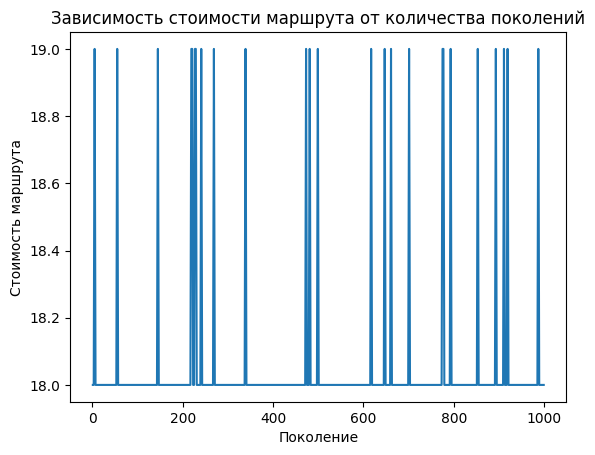

In [13]:
best_costs = []

for generation in range(1, 1000, 2):
    n_cities = len(distance_matrix)
    best_route, best_cost = genetic_algorithm(population_size=20, generations=generation, n_cities=n_cities)

    city_labels = ["A", "B", "C", "D", "E"]
    route_names = [city_labels[i] for i in best_route]
    best_costs.append(best_cost)

import matplotlib.pyplot as plt

plt.plot(range(1, 1000, 2), best_costs)
plt.xlabel("Поколение")
plt.ylabel("Стоимость маршрута")
plt.title("Зависимость стоимости маршрута от количества поколений")
plt.show()

**Вывод:** Как мы видим, что генетический алгоритм может и при 900+ поколений не дать лучший результат для задачи коммивояжера.

Проверим как устойчив алгоритм от начальной популяций, посчитав процент правильных решений для 100 поколений.

In [17]:
def evaluate_stability(num_runs=1000, max_generations=100, population_size=20, n_cities=5):
    stability_results = []  # Для хранения результатов оценки зависимости от начальной точки


    # Оценка зависимости от начальной точки
    for _ in range(num_runs):
        best_route, best_cost = genetic_algorithm(population_size, max_generations, n_cities)
        stability_results.append(best_cost == 18)

    # Печать и визуализация
    print(f"Точность решения: {np.mean(stability_results)}")

evaluate_stability();

Точность решения: 0.959


Точность алгоритма на этой задаче от разных стартовых позиций равна примерно 96%, что является хорошим результатом для метаэвристического алгоритма. Но всё-таки ожидать, что алгоритм точно найдет лучшее решение нельзя. 